In [ ]:
# RUN IF RESTARTING RUNTIME
# Mounting google drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# RUN IF RESTARTING RUNTIME
# setting up kaggle credentials
import os
os.makedirs('/root/.kaggle', exist_ok=True)

kaggle_json = '{"username":"vriddhimittal14","key":"KGAT_bb271812ebb7cd622170595febf01080"}'

with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write(kaggle_json)

os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("Kaggle credentials set")

Kaggle credentials set


In [7]:
# downloading dataset from kaggle
os.chdir('/content')

!kaggle datasets download -d gradientvoyager/faceforensics-c23-extracted-faces-100k

print("Download complete")

Dataset URL: https://www.kaggle.com/datasets/gradientvoyager/faceforensics-c23-extracted-faces-100k
License(s): CC-BY-NC-SA-4.0
Resuming from 127926272 bytes (2518225711 bytes left)...
 21% 523M/2.46G [00:22<01:53, 18.5MB/s]
User cancelled operation
Download complete


In [5]:
# unzipping dataset
import zipfile

print("Unzipping...")
with zipfile.ZipFile('/content/faceforensics-c23-extracted-faces-100k.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')
print("Done unzipping")

# Check structure
import os
for item in os.listdir('/content/dataset'):
    print(item)

Unzipping...


BadZipFile: File is not a zip file

In [6]:
# checking dataset structure
dataset_root = '/content/dataset/dataset_processed_split'
for split in os.listdir(dataset_root):
    split_path = os.path.join(dataset_root, split)
    if os.path.isdir(split_path):
        methods = os.listdir(split_path)
        print(f"{split}: {methods}")

FileNotFoundError: [Errno 2] No such file or directory: '/content/dataset/dataset_processed_split'

In [ ]:
# RUN IF RESTARTING RUNTIME
# copying dataset to google drive
import shutil

drive_dataset_path = '/content/drive/MyDrive/deepfake-detection/dataset'

if not os.path.exists(drive_dataset_path):
    print("Copying dataset to Drive... this takes ~10 minutes")
    shutil.copytree('/content/dataset/dataset_processed_split', drive_dataset_path)
    print("Done! Dataset saved to Drive permanently")
else:
    print("Dataset already on Drive, skipping copy")

Dataset already on Drive, skipping copy


In [9]:
import os
result = os.popen('du -sh /content/drive/MyDrive/deepfake-detection/dataset 2>/dev/null').read()
print(result)

KeyboardInterrupt: 

In [ ]:
# RUN IF RESTARTING RUNTIME
# cloning repo into colab
import os
os.chdir('/content')

if not os.path.exists('/content/deepfake-detection'):
    !git clone https://github.com/MunazzaNadir/deepfake-detection.git
else:
    !cd /content/deepfake-detection && git pull

os.chdir('/content/deepfake-detection')
!mkdir -p results/checkpoints results/metrics results/plots
print("Repo ready")

Cloning into 'deepfake-detection'...
remote: Enumerating objects: 47, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 47 (delta 22), reused 31 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (47/47), 14.62 KiB | 14.62 MiB/s, done.
Resolving deltas: 100% (22/22), done.
Repo ready


In [ ]:
# RUN IF RESTARTING RUNTIME
# installing requirements
!pip install -q -r requirements.txt
print("Requirements installed")

Requirements installed


In [14]:
from pathlib import Path
import pandas as pd

# Use local dataset, not Drive
DATASET_ROOT = Path("/content/dataset/dataset_processed_split")
USE_METHODS = ["Real", "Deepfakes", "Face2Face", "FaceSwap", "NeuralTextures"]

rows = []
for split in ["train", "val", "test"]:
    for method in USE_METHODS:
        folder = DATASET_ROOT / split / method
        if not folder.exists():
            print(f"WARNING: {folder} does not exist")
            continue
        image_paths = list(folder.rglob("*.jpg"))
        label = 0 if method == "Real" else 1
        for path in image_paths:
            rows.append({
                "path": str(path),
                "split": split,
                "method": method,
                "label": label,
            })

index_df = pd.DataFrame(rows)
index_df.to_csv("dataset_index.csv", index=False)
print(index_df.shape)
print(index_df.groupby(["split", "method", "label"]).size())

In [15]:
os.chdir('/content/deepfake-detection')
!git pull
print("Code updated")

In [16]:
# running experiments
!python -m src.run_vriddhi_experiments \
    --output_dir "/content/drive/MyDrive/deepfake-detection/vriddhi_results" \
    --csv_path dataset_index.csv

In [ ]:
# RUN IF RESTARTING RUNTIME
import shutil
shutil.copytree(
    '/content/drive/MyDrive/deepfake-detection/vriddhi_results/checkpoints',
    'results/checkpoints',
    dirs_exist_ok=True
)
shutil.copytree(
    '/content/drive/MyDrive/deepfake-detection/vriddhi_results/metrics',
    'results/metrics',
    dirs_exist_ok=True
)
print("Restored checkpoints and metrics from Drive")
!ls results/checkpoints
!ls results/metrics

Restored checkpoints and metrics from Drive
baseline_holdout_Deepfakes.pt	    dual_holdout_Deepfakes.pt
baseline_holdout_Face2Face.pt	    dual_holdout_Face2Face.pt
baseline_holdout_FaceSwap.pt	    dual_holdout_FaceSwap.pt
baseline_holdout_NeuralTextures.pt  dual_holdout_NeuralTextures.pt
baseline_holdout_Deepfakes.json       dual_holdout_Face2Face.json
baseline_holdout_Face2Face.json       dual_holdout_FaceSwap.json
baseline_holdout_FaceSwap.json	      dual_holdout_NeuralTextures.json
baseline_holdout_NeuralTextures.json  vriddhi_summary.csv
dual_holdout_Deepfakes.json


In [ ]:
# RUN IF RESTARTING RUNTIME
!pip install -q kaggle
import os
os.makedirs('/root/.kaggle', exist_ok=True)
kaggle_json = '{"username":"vriddhimittal14","key":"KGAT_bb271812ebb7cd622170595febf01080"}'
with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write(kaggle_json)
os.chmod('/root/.kaggle/kaggle.json', 0o600)

os.chdir('/content')
!kaggle datasets download -d gradientvoyager/faceforensics-c23-extracted-faces-100k
print("Download done")

Dataset URL: https://www.kaggle.com/datasets/gradientvoyager/faceforensics-c23-extracted-faces-100k
License(s): CC-BY-NC-SA-4.0
Resuming from 548405248 bytes (2097746735 bytes left)...
100% 2.46G/2.46G [01:45<00:00, 19.9MB/s]

Download done


In [ ]:
# RUN IF RESTARTING RUNTIME
import zipfile
print("Unzipping...")
with zipfile.ZipFile('/content/faceforensics-c23-extracted-faces-100k.zip', 'r') as z:
    z.extractall('/content/dataset')
print("Done")

Unzipping...
Done


In [17]:
# RUN IF RESTARTING RUNTIME
import os
os.chdir('/content/deepfake-detection')

from pathlib import Path
import pandas as pd

DATASET_ROOT = Path("/content/dataset/dataset_processed_split")
USE_METHODS = ["Real", "Deepfakes", "Face2Face", "FaceSwap", "NeuralTextures"]
rows = []
for split in ["train", "val", "test"]:
    for method in USE_METHODS:
        folder = DATASET_ROOT / split / method
        if not folder.exists():
            continue
        for path in folder.rglob("*.jpg"):
            rows.append({"path": str(path), "split": split, "method": method, "label": 0 if method == "Real" else 1})
pd.DataFrame(rows).to_csv("dataset_index.csv", index=False)
print("dataset_index.csv ready")

dataset_index.csv ready


In [18]:
# RUN IF RESTARTING RUNTIME
# running faceswap analysis
!python -m src.faceswap_analysis \
    --checkpoint_path results/checkpoints/baseline_holdout_FaceSwap.pt \
    --csv_path dataset_index.csv \
    --output_dir "/content/drive/MyDrive/deepfake-detection/vriddhi_results/faceswap_analysis" \
    --model_type baseline

Device: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100% 20.5M/20.5M [00:00<00:00, 223MB/s]

Running inference on 7988 samples (FaceSwap + Real test set)...

Average predicted fake probability:
  FaceSwap : 0.0621  (n=4044)
  Real     : 0.0849  (n=3944)
Saved confusion matrix → /content/drive/MyDrive/deepfake-detection/vriddhi_results/faceswap_analysis/confusion_matrix.png

FaceSwap false negatives: 3860 / 4044
Saved 10 false negative images → /content/drive/MyDrive/deepfake-detection/vriddhi_results/faceswap_analysis/false_negatives


In [19]:
# RUN IF RESTARTING RUNTIME
# dual model analysis
!python -m src.faceswap_analysis \
    --checkpoint_path results/checkpoints/dual_holdout_FaceSwap.pt \
    --csv_path dataset_index.csv \
    --output_dir "/content/drive/MyDrive/deepfake-detection/vriddhi_results/faceswap_analysis_dual" \
    --model_type dual

Device: cuda

Running inference on 7988 samples (FaceSwap + Real test set)...

Average predicted fake probability:
  FaceSwap : 0.1335  (n=4044)
  Real     : 0.2110  (n=3944)
Saved confusion matrix → /content/drive/MyDrive/deepfake-detection/vriddhi_results/faceswap_analysis_dual/confusion_matrix.png

FaceSwap false negatives: 3549 / 4044
Saved 10 false negative images → /content/drive/MyDrive/deepfake-detection/vriddhi_results/faceswap_analysis_dual/false_negatives


In [ ]:
# RUN IF RESTARTING RUNTIME
import os
os.makedirs('/content/drive/MyDrive/deepfake-detection/vriddhi_results/plots', exist_ok=True)
print("Plots folder ready")

Plots folder ready


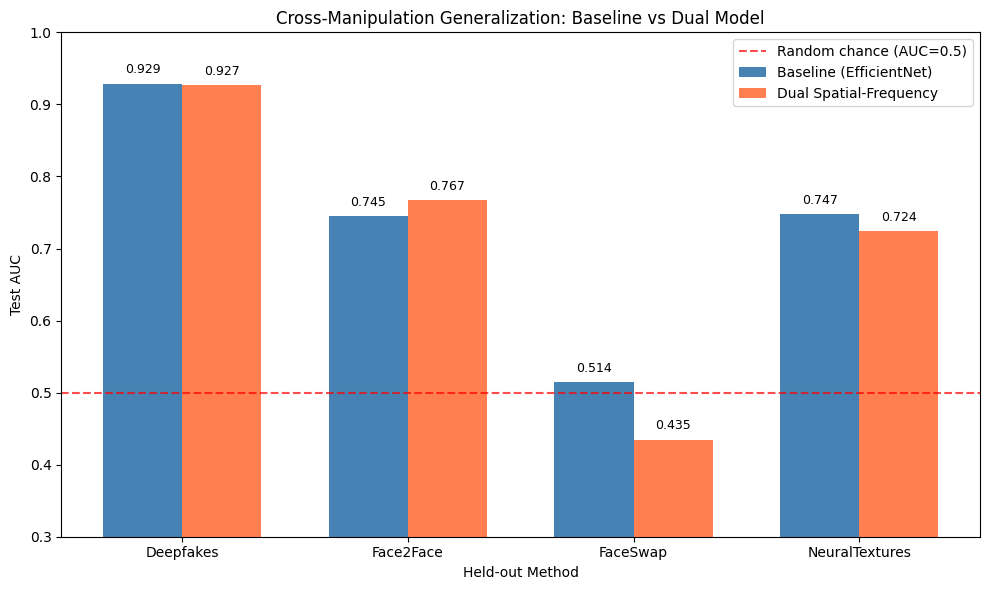

Saved plot 1


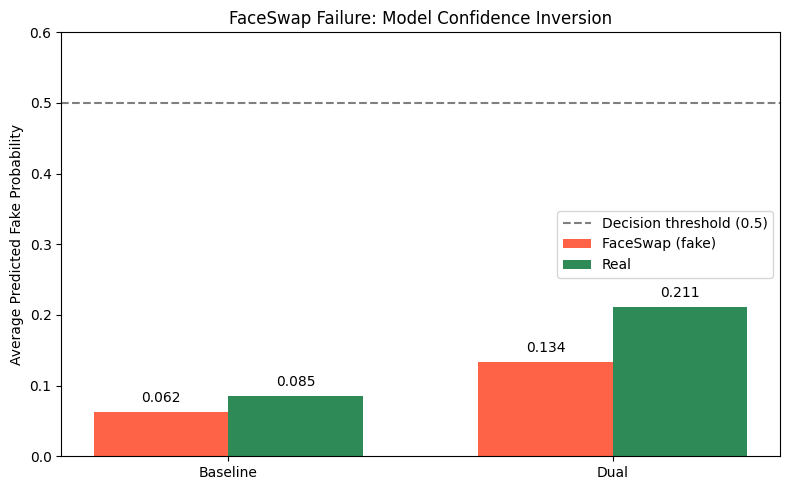

Saved plot 2


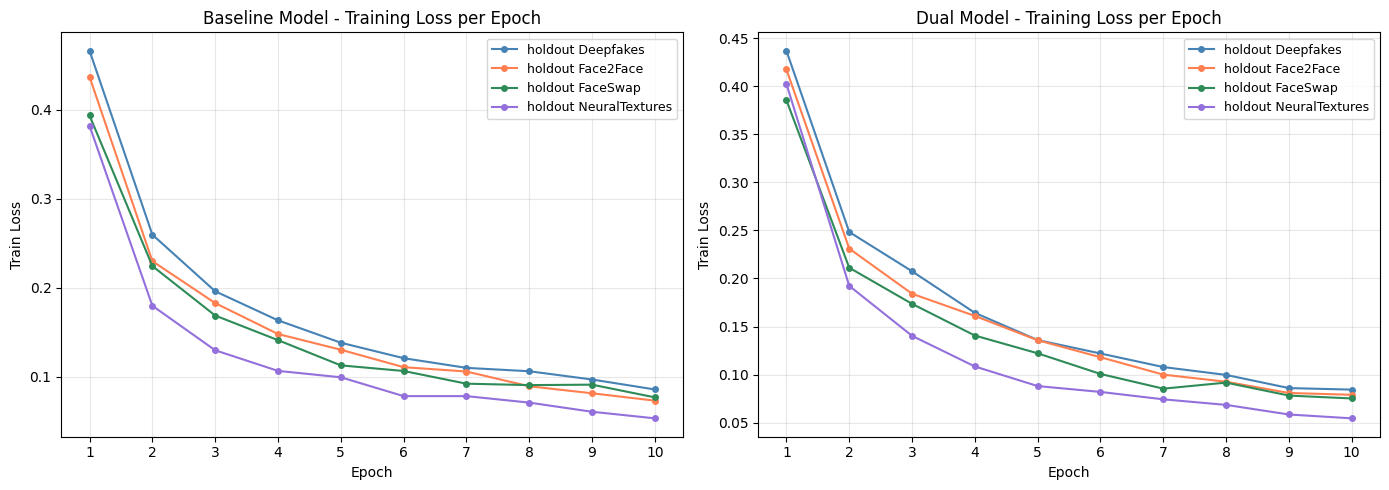

Saved plot 3

All plots saved to Drive!


In [24]:
# RUN IF RESTARTING RUNTIME
# visualization code
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Load all results
methods = ["Deepfakes", "Face2Face", "FaceSwap", "NeuralTextures"]
baseline_aucs = []
dual_aucs = []

for method in methods:
    with open(f"results/metrics/baseline_holdout_{method}.json") as f:
        baseline_aucs.append(json.load(f)["test_metrics"]["auc"])
    with open(f"results/metrics/dual_holdout_{method}.json") as f:
        dual_aucs.append(json.load(f)["test_metrics"]["auc"])

# Plot 1: Baseline vs Dual AUC by held-out method
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(methods))
width = 0.35
bars1 = ax.bar(x - width/2, baseline_aucs, width, label='Baseline (EfficientNet)', color='steelblue')
bars2 = ax.bar(x + width/2, dual_aucs, width, label='Dual Spatial-Frequency', color='coral')
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='Random chance (AUC=0.5)')
ax.set_xlabel('Held-out Method')
ax.set_ylabel('Test AUC')
ax.set_title('Cross-Manipulation Generalization: Baseline vs Dual Model')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylim(0.3, 1.0)
ax.legend()
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/deepfake-detection/vriddhi_results/plots/baseline_vs_dual_auc.png', dpi=150)
plt.show()
print("Saved plot 1")

# Plot 2: FaceSwap prediction probability comparison
fig, ax = plt.subplots(figsize=(8, 5))
models = ['Baseline', 'Dual']
faceswap_probs = [0.0621, 0.1335]
real_probs = [0.0849, 0.2110]
x = np.arange(len(models))
width = 0.35
ax.bar(x - width/2, faceswap_probs, width, label='FaceSwap (fake)', color='tomato')
ax.bar(x + width/2, real_probs, width, label='Real', color='seagreen')
ax.axhline(y=0.5, color='black', linestyle='--', alpha=0.5, label='Decision threshold (0.5)')
ax.set_ylabel('Average Predicted Fake Probability')
ax.set_title('FaceSwap Failure: Model Confidence Inversion')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 0.6)
ax.legend()
for bars in [ax.containers[0], ax.containers[1]]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/deepfake-detection/vriddhi_results/plots/faceswap_confidence_inversion.png', dpi=150)
plt.show()
print("Saved plot 2")

# Plot 3: Training loss curves (hardcoded from training output)
epochs = list(range(1, 11))
train_losses = {
    'baseline': {
        'Deepfakes':       [0.4667, 0.2597, 0.1960, 0.1633, 0.1381, 0.1207, 0.1098, 0.1060, 0.0967, 0.0855],
        'Face2Face':       [0.4373, 0.2299, 0.1827, 0.1479, 0.1302, 0.1106, 0.1057, 0.0891, 0.0812, 0.0729],
        'FaceSwap':        [0.3938, 0.2244, 0.1687, 0.1410, 0.1126, 0.1063, 0.0920, 0.0904, 0.0909, 0.0766],
        'NeuralTextures':  [0.3822, 0.1797, 0.1296, 0.1064, 0.0992, 0.0780, 0.0780, 0.0707, 0.0604, 0.0530],
    },
    'dual': {
        'Deepfakes':       [0.4371, 0.2484, 0.2075, 0.1642, 0.1359, 0.1219, 0.1078, 0.0996, 0.0859, 0.0843],
        'Face2Face':       [0.4176, 0.2311, 0.1841, 0.1610, 0.1357, 0.1180, 0.0999, 0.0925, 0.0808, 0.0789],
        'FaceSwap':        [0.3857, 0.2112, 0.1736, 0.1406, 0.1221, 0.1006, 0.0853, 0.0916, 0.0781, 0.0751],
        'NeuralTextures':  [0.4025, 0.1923, 0.1403, 0.1084, 0.0880, 0.0819, 0.0742, 0.0684, 0.0584, 0.0544],
    }
}
colors = ['steelblue', 'coral', 'seagreen', 'mediumpurple']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, model_type in zip(axes, ['baseline', 'dual']):
    for i, method in enumerate(methods):
        ax.plot(epochs, train_losses[model_type][method],
                label=f'holdout {method}', color=colors[i], marker='o', markersize=4)
    ax.set_title(f'{model_type.capitalize()} Model - Training Loss per Epoch')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Train Loss')
    ax.set_xticks(epochs)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/deepfake-detection/vriddhi_results/plots/training_curves.png', dpi=150)
plt.show()
print("Saved plot 3")

print("\nAll plots saved to Drive!")

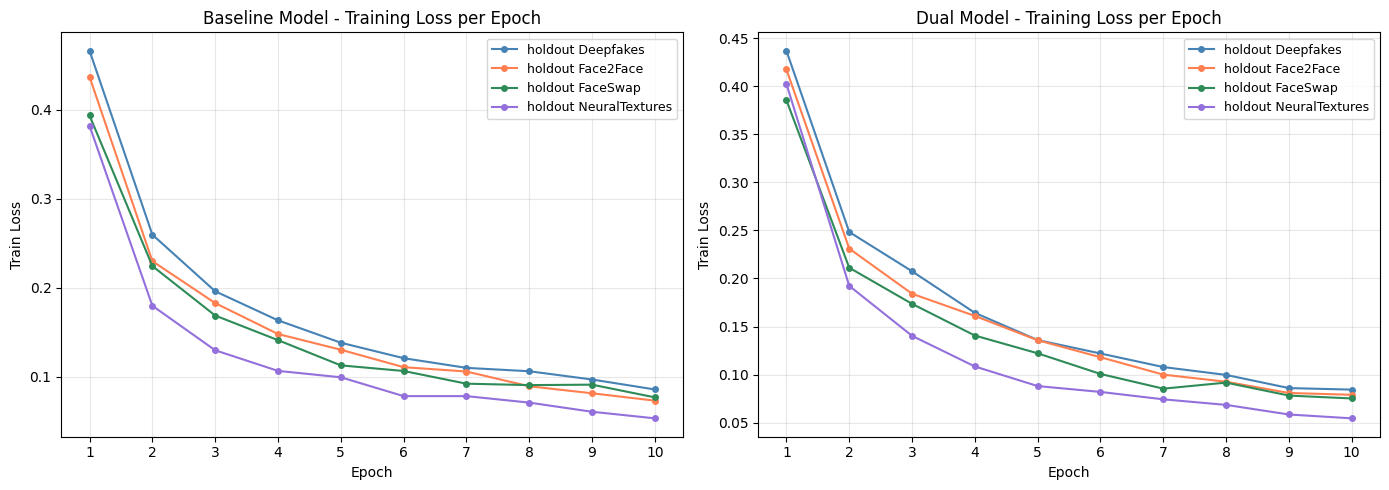

Saved training curves plot


In [23]:
import matplotlib.pyplot as plt

epochs = list(range(1, 11))

# From your actual training output
train_losses = {
    'baseline': {
        'Deepfakes':       [0.4667, 0.2597, 0.1960, 0.1633, 0.1381, 0.1207, 0.1098, 0.1060, 0.0967, 0.0855],
        'Face2Face':       [0.4373, 0.2299, 0.1827, 0.1479, 0.1302, 0.1106, 0.1057, 0.0891, 0.0812, 0.0729],
        'FaceSwap':        [0.3938, 0.2244, 0.1687, 0.1410, 0.1126, 0.1063, 0.0920, 0.0904, 0.0909, 0.0766],
        'NeuralTextures':  [0.3822, 0.1797, 0.1296, 0.1064, 0.0992, 0.0780, 0.0780, 0.0707, 0.0604, 0.0530],
    },
    'dual': {
        'Deepfakes':       [0.4371, 0.2484, 0.2075, 0.1642, 0.1359, 0.1219, 0.1078, 0.0996, 0.0859, 0.0843],
        'Face2Face':       [0.4176, 0.2311, 0.1841, 0.1610, 0.1357, 0.1180, 0.0999, 0.0925, 0.0808, 0.0789],
        'FaceSwap':        [0.3857, 0.2112, 0.1736, 0.1406, 0.1221, 0.1006, 0.0853, 0.0916, 0.0781, 0.0751],
        'NeuralTextures':  [0.4025, 0.1923, 0.1403, 0.1084, 0.0880, 0.0819, 0.0742, 0.0684, 0.0584, 0.0544],
    }
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['steelblue', 'coral', 'seagreen', 'mediumpurple']

for ax, model_type in zip(axes, ['baseline', 'dual']):
    for i, method in enumerate(['Deepfakes', 'Face2Face', 'FaceSwap', 'NeuralTextures']):
        ax.plot(epochs, train_losses[model_type][method], 
                label=f'holdout {method}', color=colors[i], marker='o', markersize=4)
    ax.set_title(f'{model_type.capitalize()} Model - Training Loss per Epoch')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Train Loss')
    ax.set_xticks(epochs)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/deepfake-detection/vriddhi_results/plots/training_curves.png', dpi=150)
plt.show()
print("Saved training curves plot")